# Punto 3 — Chatbot con RAG

Un chatbot que responde preguntas (PDF, TXT o MD), con la fuente y la página de cada respuesta.

Sigue el flujo de **RAG **:

**Cómo funciona sin GPU ni API key:** el notebook usa embeddings semánticos multilingües si puede descargarlos (en Colab sí) y, si no, usa TF-IDF. Para generar la respuesta usa un LLM local con **Ollama** (como sugiere el documento) si lo activas; si no, arma la respuesta extrayendo las frases más relevantes de los documentos.

In [2]:
!pip -q install pypdf scikit-learn sentence-transformers

**Qué hace:** instala las librerías. `pypdf` lee PDFs, `scikit-learn` aporta TF-IDF y PCA, y `sentence-transformers` los embeddings semánticos.

In [3]:
import os, re, glob
import numpy as np
from pypdf import PdfReader

CARPETA = "documentos"
os.makedirs(CARPETA, exist_ok=True)

# En Colab: subir los archivos del curso
try:
    from google.colab import files
    print("Sube los documentos del curso (PDF, TXT o MD):")
    subidos = files.upload()
    for nombre, contenido in subidos.items():
        with open(os.path.join(CARPETA, nombre), "wb") as f:
            f.write(contenido)
except ImportError:
    print("Fuera de Colab: copia tus archivos a la carpeta 'documentos/'")

def limpiar(texto):
    return re.sub(r"\s+", " ", texto).strip()

def leer_documento(ruta):
    """Devuelve una lista de (numero_de_pagina, texto)."""
    if ruta.lower().endswith(".pdf"):
        lector = PdfReader(ruta)
        return [(i + 1, limpiar(p.extract_text() or "")) for i, p in enumerate(lector.pages)]
    with open(ruta, encoding="utf-8", errors="ignore") as f:
        return [(1, limpiar(f.read()))]

documentos = {}
for ruta in sorted(glob.glob(os.path.join(CARPETA, "*"))):
    if ruta.lower().endswith((".pdf", ".txt", ".md")):
        documentos[os.path.basename(ruta)] = leer_documento(ruta)

for nombre, paginas in documentos.items():
    palabras = sum(len(t.split()) for _, t in paginas)
    print(f"📄 {nombre}: {len(paginas)} páginas, {palabras} palabras")

Sube los documentos del curso (PDF, TXT o MD):


Saving 7. Gen Ai 2026 2.pdf to 7. Gen Ai 2026 2.pdf
📄 7. Gen Ai 2026 2.pdf: 23 páginas, 7769 palabras


Carga los documentos. En Colab  abre un botón para subir los archivos; fuera de Colab lee la carpeta `documentos/`. Cada PDF se convierte en texto **página por página**, para poder citar la página luego. Si un PDF es solo imágenes escaneadas, no saldrá texto.

In [4]:
def dividir_en_chunks(paginas, nombre, tam=110, solape=25):
    """Corta cada página en trozos de ~110 palabras que se solapan 25 palabras."""
    chunks = []
    paso = tam - solape
    for pagina, texto in paginas:
        palabras = texto.split()
        for ini in range(0, len(palabras), paso):
            fragmento = palabras[ini:ini + tam]
            if len(fragmento) >= 15:
                chunks.append({"fuente": nombre, "pagina": pagina, "texto": " ".join(fragmento)})
            if ini + tam >= len(palabras):
                break
    return chunks

chunks = []
for nombre, paginas in documentos.items():
    chunks += dividir_en_chunks(paginas, nombre)

print(f"{len(chunks)} chunks")
print("\nEjemplo de chunk:")
print(chunks[len(chunks)//2])

95 chunks

Ejemplo de chunk:
{'fuente': '7. Gen Ai 2026 2.pdf', 'pagina': 14, 'texto': 'palabra en inglés correspondiente y las palabras predichas al francés que lleva. Al enmascarar cada palabra en francés, evitamos que el modelo simplemente memorice los pares entrada -salida y lo anima a aprender patrones ocultos y relaciones entre los dos lenguajes. Cuando se procesa la frase en francés en el bloque decoder, solam ente podemos usar las palabras previamente generadas en francés para predecir la palabra siguiente. Par lograr esto, se enmascaran todas las futuras palabras en francés transformándolas en 0s. Esto se hace creando una matriz de máscara con la misma forma de la matriz de atención, con valores de 1 para la correspondiente palabra en francés que está'}


Divide el texto en **chunks** (trozos de ~110 palabras). Se hace porque el modelo tiene una ventana de contexto limitada y porque buscar en trozos pequeños es más preciso que buscar en documentos enteros. El **solape** de 25 palabras evita que una idea se parta justo por la mitad entre dos chunks.

In [7]:
from scipy.sparse import issparse, hstack
from sklearn.feature_extraction.text import TfidfVectorizer

USAR_SEMANTICO = True   # False = usar siempre TF-IDF

STOP_ES = ["de","la","el","en","y","a","los","las","un","una","unos","unas","que","es","se","por","con","para",
           "del","al","lo","como","mas","pero","su","sus","o","si","ha","son","este","esta","esto","ese","esa",
           "entre","sobre","tambien","muy","ya","le","les","me","mi","te","tu","nos","hay","ser","fue","era",
           "cual","cuales","cuando","donde","quien","cuanto","sin","hacia","desde","segun","hace"]

class Embedder:
    """Convierte texto en vectores. Semantico (sentence-transformers) o TF-IDF."""
    def __init__(self, textos_de_entrenamiento):
        self.modo = "tfidf"
        if USAR_SEMANTICO:
            try:
                from sentence_transformers import SentenceTransformer
                self.modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
                self.modo = "semantico"
            except Exception as e:
                print("No pude cargar el modelo semántico (", type(e).__name__, ") -> uso TF-IDF")
        if self.modo == "tfidf":
            # Dos "miradas" combinadas: palabras completas y trozos de 4-5 letras
            # (con trozos, "enmascaramiento" y "enmascarar" se parecen aunque no sean iguales)
            self.tf_palabras = TfidfVectorizer(strip_accents="unicode", sublinear_tf=True, ngram_range=(1, 2),
                                               stop_words=STOP_ES, token_pattern=r"(?u)\b\w+\b").fit(textos_de_entrenamiento)
            self.tf_letras = TfidfVectorizer(strip_accents="unicode", sublinear_tf=True, analyzer="char_wb",
                                             ngram_range=(4, 5)).fit(textos_de_entrenamiento)

    def codificar(self, textos):
        if self.modo == "semantico":
            return self.modelo.encode(textos, normalize_embeddings=True, show_progress_bar=False)
        # Se pegan los dos vectores con peso 1/2 cada uno: el producto punto resultante es el promedio
        # de las dos similitudes de coseno, y el vector sigue con norma 1.
        return hstack([0.7071 * self.tf_palabras.transform(textos),
                       0.7071 * self.tf_letras.transform(textos)]).tocsr()

    def similitud(self, consulta, textos):
        """Similitud de coseno entre la consulta y cada texto (vectores normalizados -> producto punto)."""
        q = self.codificar([consulta])
        M = self.codificar(textos)
        s = M @ q.T
        return (s.toarray() if issparse(s) else s).ravel()

class BaseVectorial:
    """Una 'base de datos vectorial' mínima: una matriz con un vector por chunk."""
    def __init__(self, chunks):
        self.chunks = chunks
        textos = [c["texto"] for c in chunks]
        self.emb = Embedder(textos)
        self.matriz = self.emb.codificar(textos)

    def buscar(self, consulta, k=3):
        q = self.emb.codificar([consulta])
        s = self.matriz @ q.T
        puntajes = (s.toarray() if issparse(s) else s).ravel()
        mejores = np.argsort(-puntajes)[:k]
        return [self.chunks[i] for i in mejores], puntajes[mejores]

base = BaseVectorial(chunks)
print("Modo de embeddings:", base.emb.modo)
print("Forma de la matriz (chunks x dimensiones):", base.matriz.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modo de embeddings: semantico
Forma de la matriz (chunks x dimensiones): (95, 384)


Convierte cada chunk en un **vector de embedding** y los guarda en una matriz, que hace de base de datos vectorial.

La **similitud de coseno** (la que explica el documento) se calcula con un producto punto, porque los vectores ya están normalizados.

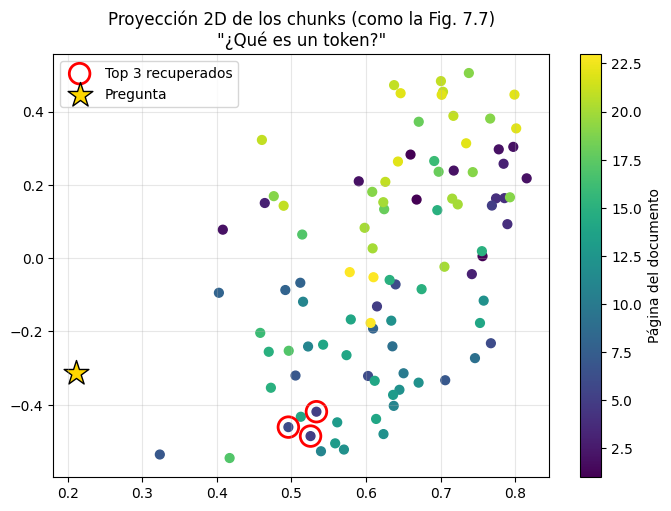

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

def mapa_de_chunks(pregunta, k=3):
    svd = TruncatedSVD(n_components=2, random_state=0)
    puntos = svd.fit_transform(base.matriz)
    q2d = svd.transform(base.emb.codificar([pregunta]))
    mejores, _ = base.buscar(pregunta, k)
    idx_mejores = [chunks.index(c) for c in mejores]

    plt.figure(figsize=(8, 5.5))
    sc = plt.scatter(puntos[:, 0], puntos[:, 1], c=[c["pagina"] for c in chunks], cmap="viridis", s=40)
    plt.colorbar(sc, label="Página del documento")
    plt.scatter(puntos[idx_mejores, 0], puntos[idx_mejores, 1], s=220, facecolors="none", edgecolors="red", linewidths=2, label=f"Top {k} recuperados")
    plt.scatter(q2d[:, 0], q2d[:, 1], marker="*", s=350, color="gold", edgecolors="black", label="Pregunta")
    plt.title(f"Proyección 2D de los chunks (como la Fig. 7.7)\n\"{pregunta}\"")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

mapa_de_chunks("¿Qué es un token?")

Reduce los vectores a 2 dimensiones (igual que el documento hace con PCA en la figura 7.7) para *ver* la base vectorial. Cada punto es un chunk, coloreado por su página; la estrella dorada es la pregunta y los círculos rojos son los chunks que se recuperan por estar más cerca de ella.

In [9]:
def mostrar_recuperacion(pregunta, k=3):
    fragmentos, puntajes = base.buscar(pregunta, k)
    print(f"Pregunta: {pregunta}\n")
    for f, p in zip(fragmentos, puntajes):
        print(f"  similitud={p:.2f} | {f['fuente']}, pág. {f['pagina']}")
        print(f"  {f['texto'][:160]}...\n")

mostrar_recuperacion("¿Para qué sirve el enmascaramiento en el decoder?")

Pregunta: ¿Para qué sirve el enmascaramiento en el decoder?

  similitud=0.74 | 7. Gen Ai 2026 2.pdf, pág. 13
  la procesa el bloque decoder. Como el bloque encoder, el bloque decoder también incluye una capa embedding y un componente encoder posicional, que convierte las...

  similitud=0.70 | 7. Gen Ai 2026 2.pdf, pág. 13
  crucial en generar la secuencia de salida con base en la representaci ón de la entrada codificada. Mientras que el encoder se enfoca en comprender la secuencia ...

  similitud=0.67 | 7. Gen Ai 2026 2.pdf, pág. 12
  al bloque encoder al mismo tiempo, produciendo un conjunto de vectores codificados para cada palabra, que se puede computar simultáneamente. 7.5.2 Decoder La ar...



Convierte la pregunta en vector y recupera los `k` chunks más parecidos, mostrando su similitud, documento y página. Esta es la parte *Retrieval* de RAG; la calidad de las respuestas depende casi por completo de que esta búsqueda traiga los chunks correctos.

In [10]:
def construir_prompt(pregunta, fragmentos):
    contexto = "\n\n".join(
        f"[{i+1}] ({f['fuente']}, pág. {f['pagina']}) {f['texto']}" for i, f in enumerate(fragmentos))
    return (
        "Eres el asistente de un curso universitario de inteligencia artificial. "
        "Responde en español usando SOLO la información de los fragmentos. "
        "Si la respuesta no está en ellos, di que no la encuentras en los documentos. "
        "Cita las fuentes como [1], [2].\n\n"
        f"FRAGMENTOS:\n{contexto}\n\nPREGUNTA: {pregunta}\n\nRESPUESTA:")

# --- Opción A: LLM local con Ollama (el documento lo sugiere) ---
import requests
USAR_OLLAMA = False
MODELO_OLLAMA = "llama3.2:3b"

def generar_con_ollama(prompt):
    r = requests.post("http://localhost:11434/api/generate",
                      json={"model": MODELO_OLLAMA, "prompt": prompt, "stream": False,
                            "options": {"temperature": 0.2}}, timeout=300)
    return r.json()["response"].strip()

# --- Opción B: sin LLM, extrae las frases más relevantes ---
def respuesta_extractiva(pregunta, fragmentos, n_frases=3):
    frases, vistas = [], []
    for i, f in enumerate(fragmentos):
        for s in re.split(r"(?<=[.!?:;])\s+", f["texto"]):
            clave = s.lower()
            # los chunks se solapan: descartamos frases repetidas o contenidas en otra ya vista
            if len(s.split()) >= 6 and not any(clave in v or v in clave for v in vistas):
                frases.append((s, i))
                vistas.append(clave)
    if not frases:
        return fragmentos[0]["texto"]
    sims = base.emb.similitud(pregunta, [s for s, _ in frases])
    sims = sims * np.array([1 - 0.12 * i for _, i in frases])   # preferimos frases de los chunks mejor rankeados
    elegidas = sorted(np.argsort(-sims)[:n_frases])        # en su orden original
    return " ".join(f"{frases[j][0]} [{frases[j][1]+1}]" for j in elegidas)

Define cómo se genera la respuesta.
- `construir_prompt` arma el mensaje que recibiría el LLM: instrucciones + fragmentos recuperados + pregunta. Es el esquema "Document Snippets / Instructions / Query" de la figura del flujo RAG del documento. La instrucción *"usa SOLO los fragmentos"* es lo que reduce las **alucinaciones**.
- **Opción A**: manda ese prompt a un LLM local con **Ollama**.
- **Opción B**: no necesita LLM; elige las frases de los chunks más parecidas a la pregunta. Es menos fluida, pero funciona en cualquier máquina y nunca inventa nada, porque solo copia lo que dicen los documentos.

In [11]:
UMBRAL = {"semantico": 0.30, "tfidf": 0.08}[base.emb.modo]   # por debajo de esto, "no sé"

def responder(pregunta, k=3, mostrar_prompt=False, consulta_busqueda=None):
    consulta = consulta_busqueda or pregunta
    fragmentos, puntajes = base.buscar(consulta, k)
    if puntajes[0] < UMBRAL:
        return "No encuentro información sobre eso en los documentos del curso."

    prompt = construir_prompt(pregunta, fragmentos)
    if mostrar_prompt:
        print("----- PROMPT ENVIADO AL LLM -----\n" + prompt + "\n---------------------------------\n")

    if USAR_OLLAMA:
        try:
            texto = generar_con_ollama(prompt)
        except Exception as e:
            print("(Ollama no respondió, uso respuesta extractiva)", type(e).__name__)
            texto = respuesta_extractiva(pregunta, fragmentos)
    else:
        texto = respuesta_extractiva(pregunta, fragmentos)

    fuentes = "; ".join(f"[{i+1}] {f['fuente']}, pág. {f['pagina']}" for i, f in enumerate(fragmentos))
    return f"{texto}\n\nFuentes: {fuentes}"

for p in ["¿Qué es un token?",
          "¿Qué necesita un agente de IA para ser útil?",
          "¿Qué es MCP?",
          "¿Cuál es la capital de Francia?"]:
    print(p)
    print(responder(p), "\n")

¿Qué es un token?
Token Un token es una unidad de datos que viene de descomponer fragmentos más grandes de información, que puede representar palabras, caracteres o frases. [1] Cuando se procesa texto, una frase se divide en tokens, donde cada palabra o signo de puntuación se conside ra un token separado. [1] • Tipos de tokens • Tokens de texto. [2]

Fuentes: [1] 7. Gen Ai 2026 2.pdf, pág. 5; [2] 7. Gen Ai 2026 2.pdf, pág. 6; [3] 7. Gen Ai 2026 2.pdf, pág. 5 

¿Qué necesita un agente de IA para ser útil?
En concreto, un agente de IA necesita tres cosas para ser útil: [1] Un modelo de IA para usar. [1] Sin embargo, donde la situación se vuelve realmente interesante es con el concepto de sistemas multiagente, que implica que varios agentes de IA trabajen juntos para responder consultas o ejecutar flujos de trabajo, imitando la colaboración humana en equipo. [2]

Fuentes: [1] 7. Gen Ai 2026 2.pdf, pág. 18; [2] 7. Gen Ai 2026 2.pdf, pág. 18; [3] 7. Gen Ai 2026 2.pdf, pág. 19 

¿Qué es MCP?

Junta todo en la función `responder`: recupera, decide si hay información suficiente, genera la respuesta y agrega las fuentes con página.

Como la pregunta, "¿Capital de Francia?" está en los documentos, la similitud es baja y el chatbot **prefiere decir que no sabe** antes que inventar. Ese es el valor central de RAG frente a un LLM solo.

In [12]:
# ¿Está bien calibrado el umbral? Compara preguntas sobre el documento vs. preguntas fuera de tema
dentro = ["¿Qué es un modelo fundamental?", "¿Qué es la similitud de coseno?", "¿Qué hace el decoder?"]
fuera  = ["¿Cuál es la capital de Francia?", "Dame una receta de arepas", "¿Quién ganó el último mundial de fútbol?"]

print(f"Modo: {base.emb.modo} | umbral actual: {UMBRAL}\n")
for etiqueta, lista in [("DENTRO del tema", dentro), ("FUERA del tema", fuera)]:
    print(etiqueta)
    for p in lista:
        print(f"   {base.buscar(p, 1)[1][0]:.2f}  {p}")

Modo: semantico | umbral actual: 0.3

DENTRO del tema
   0.63  ¿Qué es un modelo fundamental?
   0.70  ¿Qué es la similitud de coseno?
   0.67  ¿Qué hace el decoder?
FUERA del tema
   0.25  ¿Cuál es la capital de Francia?
   0.20  Dame una receta de arepas
   0.18  ¿Quién ganó el último mundial de fútbol?


Muestra la mejor similitud para preguntas del tema y fuera de él. Las de dentro deben quedar por encima del umbral y las de fuera por debajo. Si en los documentos no se separan bien, ajusta `UMBRAL` en la celda anterior. Con TF-IDF puede haber casos límite: una pregunta fuera de tema que comparte alguna palabra común con el documento (por ejemplo «último») saca una similitud más alta de lo esperado. Los embeddings semánticos separan mucho mejor esos casos, por eso son el modo recomendado en Colab.

In [13]:
# Evaluación rápida: ¿el chunk correcto aparece entre los 3 recuperados?
# (Las preguntas y palabras clave son del documento '7. Inteligencia Artificial Generativa')
pruebas = [
    ("¿Qué es un modelo fundamental?", "algoritmo de dl"),
    ("¿Para qué sirve el enmascaramiento en el decoder?", "enmascar"),
    ("¿Qué es RAG y para qué sirve?", "retrieval"),
    ("¿Cómo se calcula la similitud de coseno?", "producto punto"),
    ("¿Qué es MCP?", "usb-c"),
    ("¿Qué necesita un agente de IA para ser útil?", "memoria"),
    ("¿Qué son los vectores Q, K y V?", "consulta"),
    ("¿Qué es un chunk?", "chunks"),
    ("¿Qué es un token?", "unidad de datos"),
]
aciertos = 0
for pregunta, clave in pruebas:
    fragmentos, _ = base.buscar(pregunta, 3)
    ok = any(clave in f["texto"].lower() for f in fragmentos)
    aciertos += ok
    print("✅" if ok else "❌", pregunta)
print(f"\nAciertos: {aciertos}/{len(pruebas)} ({aciertos/len(pruebas):.0%})")

❌ ¿Qué es un modelo fundamental?
❌ ¿Para qué sirve el enmascaramiento en el decoder?
❌ ¿Qué es RAG y para qué sirve?
✅ ¿Cómo se calcula la similitud de coseno?
✅ ¿Qué es MCP?
✅ ¿Qué necesita un agente de IA para ser útil?
✅ ¿Qué son los vectores Q, K y V?
✅ ¿Qué es un chunk?
✅ ¿Qué es un token?

Aciertos: 6/9 (67%)


Mide qué tan bueno es el recuperador con 9 preguntas de las que sabemos qué palabra debe aparecer en el chunk correcto. Si recuperas el chunk correcto, el generador casi siempre acierta; si no, ni el mejor LLM puede responder bien (el documento lo dice: la eficacia de RAG depende de la calidad de la búsqueda).

In [14]:

# INTERACTIVO: conversa con tu chatbot (escribe 'salir' para terminar)
def chat():
    ultima = None
    print("Hola, pregúntame sobre los documentos del curso. ('salir' para terminar)")
    while True:
        pregunta = input("\nTú: ").strip()
        if pregunta.lower() in ("salir", "exit", ""):
            print("¡Hasta luego!")
            break
        # Memoria simple: si la pregunta es muy corta ("¿y el decoder?"), añadimos la anterior a la búsqueda
        consulta = f"{ultima} {pregunta}" if ultima and len(pregunta.split()) <= 4 else pregunta
        print(responder(pregunta, consulta_busqueda=consulta))
        ultima = pregunta

chat()

Hola, pregúntame sobre los documentos del curso. ('salir' para terminar)

Tú: que es un RAG
El enfoque RAG, en la medida en que se ha vuelto más popular, se ha hecho evidente que su eficacia depende completamente de la calidad de la búsqueda del sistema base de recuperación. [1] o "pesos de atención" que suman 100%. [2] Por ejemplo, para la palabra "banco" en la frase "Fui al banco a sacar dinero", la palabra "dinero" recibirá un peso de atención muy alto. [2]

Fuentes: [1] 7. Gen Ai 2026 2.pdf, pág. 16; [2] 7. Gen Ai 2026 2.pdf, pág. 12; [3] 7. Gen Ai 2026 2.pdf, pág. 5

Tú: Que es un token?
Token Un token es una unidad de datos que viene de descomponer fragmentos más grandes de información, que puede representar palabras, caracteres o frases. [1] Cuando se procesa texto, una frase se divide en tokens, donde cada palabra o signo de puntuación se conside ra un token separado. [1] Es el contenido real o significado del token. [2]

Fuentes: [1] 7. Gen Ai 2026 2.pdf, pág. 5; [2] 7. Gen Ai

Abre una conversación. Incluye una **memoria** mínima: si escribes una pregunta muy corta como "¿y el decoder?", se le agrega la pregunta anterior para buscar mejor (el documento menciona que un agente necesita memoria para tener contexto entre interacciones).

Conclusiones:
Después de una serie de pruebas, mandando preguntas que deberían poder ser respondidas por el chatbot, vemos que este tiende a equivocarse bastante en definiciones. Al momento de que el modelo halla una palabra clave en la pregunta, expulsa una respuesta que tenga esta palabra clave sin ver necesariamente el contexto de la pregunta, como lo puede ser ¿Que es ...? ¿Que significa ..? Que similitudes hay entre los ... y los ....? Etc. Sin embargo para el tamaño del chatbot, y la cantidad de información que resive de un único PDF, se puede entender el porque de este comportamiento